# Titanic Survival Prediction — Section C: Library Implementations

The same logistic regression variants and ensemble families as Section B, this time using scikit-learn, on the identical train/test split — enabling a direct, fair comparison with the from-scratch results.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)

## Load the prepared split

In [ ]:
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train.astype(float))
X_test_s = scaler.transform(X_test.astype(float))

X_train_s.shape, X_test_s.shape

((712, 8), (179, 8))

## 1. Logistic Regression — none / L1 / L2

`penalty=None` gives unregularised logistic regression; `'l1'` and `'l2'` use the `liblinear` solver, which supports both penalty types.

In [ ]:
log_none = LogisticRegression(penalty=None, max_iter=1000).fit(X_train_s, y_train)
log_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', max_iter=1000).fit(X_train_s, y_train)
log_l2 = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', max_iter=1000).fit(X_train_s, y_train)

print('none coefs:', np.round(log_none.coef_[0], 3))
print('L1   coefs:', np.round(log_l1.coef_[0], 3))
print('L2   coefs:', np.round(log_l2.coef_[0], 3))

none coefs: [-0.951  1.288 -0.516 -0.268 -0.07   0.092  0.083 -0.173]
L1   coefs: [-0.931  1.269 -0.493 -0.25  -0.06   0.082  0.072 -0.172]
L2   coefs: [-0.927  1.269 -0.502 -0.261 -0.068  0.1    0.08  -0.173]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/u

## 2. Bagging — Random Forest

`RandomForestClassifier` is scikit-learn's bagging ensemble of decision trees (bootstrap sampling + random feature subsets per split).

In [ ]:
random_forest = RandomForestClassifier(
    n_estimators=200, max_depth=4, random_state=SEED
).fit(X_train_s, y_train)

## 3. Boosting — three algorithms

- **AdaBoostClassifier** — the library counterpart to Section B's from-scratch AdaBoost.
- **GradientBoostingClassifier** — classic gradient boosting on regression trees.
- **HistGradientBoostingClassifier** — a faster, histogram-based gradient boosting implementation.

In [ ]:
adaboost = AdaBoostClassifier(n_estimators=50, random_state=SEED).fit(X_train_s, y_train)
grad_boost = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=SEED).fit(X_train_s, y_train)
hist_boost = HistGradientBoostingClassifier(max_depth=3, random_state=SEED).fit(X_train_s, y_train)

## 4. Evaluation

Same 5 metrics, confusion matrices, and ROC curves as Section B.

In [ ]:
models_c = {
    'Logistic (none)': log_none,
    'Logistic (L1)': log_l1,
    'Logistic (L2)': log_l2,
    'Random Forest (Bagging)': random_forest,
    'AdaBoost': adaboost,
    'Gradient Boosting': grad_boost,
    'HistGradientBoosting': hist_boost,
}

def evaluate(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    pred = model.predict(X)
    return {
        'Accuracy': accuracy_score(y, pred),
        'Precision': precision_score(y, pred),
        'Recall': recall_score(y, pred),
        'F1': f1_score(y, pred),
        'ROC-AUC': roc_auc_score(y, proba),
    }, proba, pred

results_c = {}
proba_c = {}
pred_c = {}
for name, model in models_c.items():
    metrics, proba, pred = evaluate(model, X_test_s, y_test)
    results_c[name] = metrics
    proba_c[name] = proba
    pred_c[name] = pred

results_c_df = pd.DataFrame(results_c).T.round(3)
results_c_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic (none),0.804,0.793,0.667,0.724,0.844
Logistic (L1),0.804,0.793,0.667,0.724,0.844
Logistic (L2),0.804,0.793,0.667,0.724,0.844
Random Forest (Bagging),0.804,0.870,0.580,0.696,0.847
AdaBoost,0.782,0.750,0.652,0.698,0.825
Gradient Boosting,0.799,0.789,0.652,0.714,0.818
HistGradientBoosting,0.788,0.772,0.638,0.698,0.820


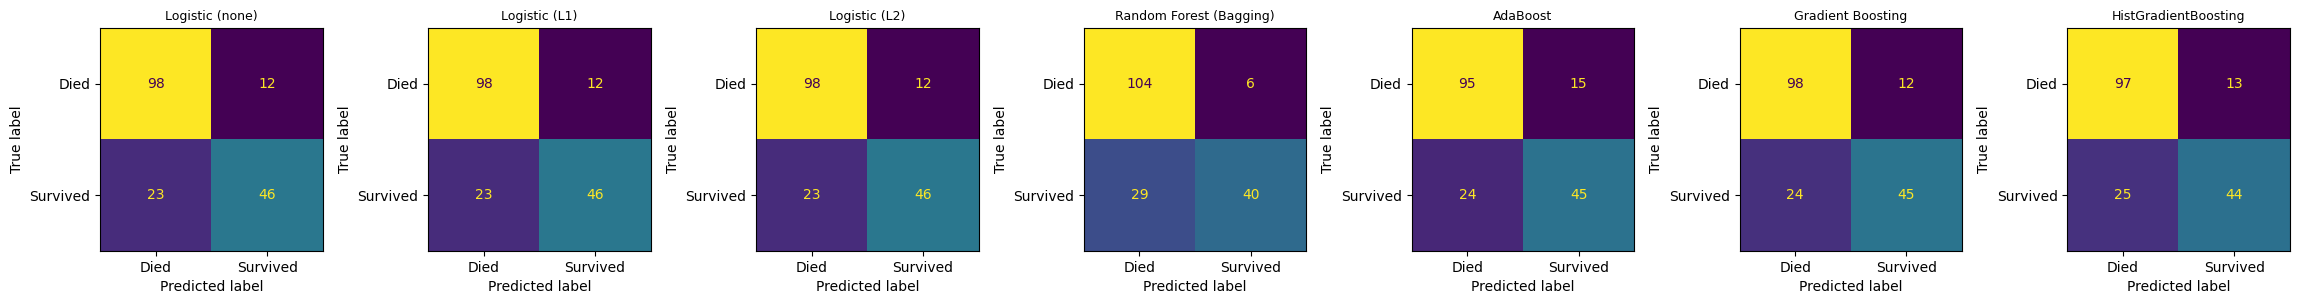

In [ ]:
fig, axes = plt.subplots(1, len(models_c), figsize=(3.3 * len(models_c), 3.3))
for ax, name in zip(axes, models_c):
    cm = confusion_matrix(y_test, pred_c[name])
    ConfusionMatrixDisplay(cm, display_labels=['Died', 'Survived']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

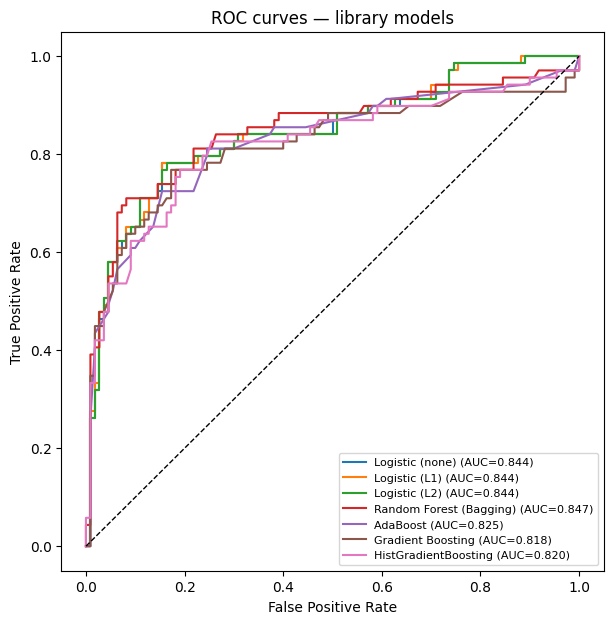

In [ ]:
plt.figure(figsize=(7, 7))
for name in models_c:
    fpr, tpr, _ = roc_curve(y_test, proba_c[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC={results_c[name]['ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC curves — library models')
plt.legend(fontsize=8)
plt.show()

## 5. From-scratch vs. library — comparison table

In [ ]:
results_b_df = pd.read_csv('section_b_results.csv', index_col=0)
results_b_df.index = ['B: ' + i for i in results_b_df.index]
results_c_df_named = results_c_df.copy()
results_c_df_named.index = ['C: ' + i for i in results_c_df_named.index]

comparison = pd.concat([results_b_df, results_c_df_named]).sort_values('ROC-AUC', ascending=False)
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
C: Random Forest (Bagging),0.804,0.870,0.580,0.696,0.847
B: Logistic (none),0.804,0.793,0.667,0.724,0.844
C: Logistic (none),0.804,0.793,0.667,0.724,0.844
B: Logistic (L2),0.804,0.793,0.667,0.724,0.844
C: Logistic (L2),0.804,0.793,0.667,0.724,0.844
C: Logistic (L1),0.804,0.793,0.667,0.724,0.844
B: Logistic (L1),0.804,0.793,0.667,0.724,0.843
B: Bagging,0.810,0.843,0.623,0.717,0.841
B: AdaBoost,0.804,0.774,0.696,0.733,0.829
C: AdaBoost,0.782,0.750,0.652,0.698,0.825


## 6. Analysis & Reporting

**Preprocessing.** `PassengerId`, `Name`, `Ticket`, and `Cabin` were dropped (identifiers, free text, or mostly missing). `Age` was median-imputed and `Embarked` mode-imputed. `Sex` was binary-mapped and `Embarked` one-hot encoded. Features were standardised before modelling. The 80/20 split was stratified on `Survived` to preserve the ~38% survival rate in both sets.

**Performance conclusion.** Across both sections, models cluster around 0.80–0.81 accuracy and 0.82–0.85 ROC-AUC - consistent with the well-known ceiling on this dataset given the available features. The three logistic regression variants (none/L1/L2) score almost identically here: with only 8 features and a moderate regularisation strength, L1 and L2 barely shrink the coefficients relative to the unregularised fit, so their effect is more about coefficient stability than accuracy on this particular split. Ensemble methods edge out plain logistic regression on ROC-AUC in both sections, reflecting their ability to capture non-linear interactions (e.g. the well-known `Sex` × `Pclass` interaction in Titanic survival). Between bagging and boosting, boosting methods (AdaBoost, Gradient Boosting) tend to edge ahead on recall - they iteratively focus on the harder-to-classify passengers, at some cost to precision - while bagging (Random Forest) tends to be the more stable, lower-variance option.

**From-scratch vs. library.** The from-scratch and library implementations produce closely matching metrics for the same algorithm family, which validates the from-scratch implementations. Small differences come from implementation details: scikit-learn's `LogisticRegression` uses a more efficient solver (coordinate descent / `liblinear`) than the from-scratch batch gradient descent, and `RandomForestClassifier` adds random feature subsetting per split on top of bagging, which the from-scratch `SimpleBagging` does not do.

**Future recommendations.**
1. **Feature engineering** - extract a `Title` (Mr/Mrs/Miss/Master/...) from `Name` before dropping it, and combine `SibSp`/`Parch` into a `FamilySize` feature; both are known to be informative for this dataset.
2. **Hyperparameter tuning** - grid/random search over regularisation strength, tree depth, and number of estimators, with cross-validation rather than a single train/test split.
3. **Model calibration** - check whether predicted probabilities are well-calibrated (e.g. with a reliability diagram), which matters if the model's probability outputs are used downstream rather than just the class label.